# Circulation Effects & Sentiment Distributions

Examines whether newspaper circulation (size) predicts labor coverage and sentiment,
and visualizes sentiment distributions by newspaper and by editor/owner tenure.

In [1]:
import pandas as pd
import sqlite3
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '../data/processed/newspapers.db'
OE_PATH = '../data/intermediate/personnel_coding/owners_and_editors.csv'
CODE_PATH = '../data/intermediate/personnel_coding/combined_coding.csv'

# Load intermediate data from 01_data_preparation
df = pd.read_csv('intermediate/analysis_sample.csv')
counts = pd.read_csv('intermediate/sentiment_counts.csv')
paper_year_rr = pd.read_csv('intermediate/paper_year_rr.csv')
person_rr = pd.read_csv('intermediate/person_rr.csv')

import numpy as np
import matplotlib.pyplot as plt

oe = pd.read_csv(OE_PATH)


def parse_years(s):
    if pd.isna(s):
        return []
    return [int(y.strip()) for y in str(s).split(';') if y.strip().isdigit()]


print(f'Loaded analysis sample: {len(df)} newspaper-years')

Loaded analysis sample: 319 newspaper-years


---

## 7. Circulation (Paper Size) Regressions

Does paper size (proxied by circulation) predict labor coverage volume and sentiment?

Uses circulation figures from the Ayer directories in `master.csv`. Circulation is matched to the nearest available directory year.

In [3]:
# Load and reshape circulation data from master.csv
master = pd.read_csv('../data/processed/master.csv')
circ_cols = [c for c in master.columns if 'circulation' in c.lower()]

# Melt to long format: issn Ã— year â†’ circulation
circ_long = []
for col in circ_cols:
    yr = int(col.split()[0])
    tmp = master[['issn', col]].dropna(subset=['issn', col]).copy()
    tmp = tmp.rename(columns={col: 'circulation'})
    tmp['circ_year'] = yr
    circ_long.append(tmp)

circ_long = pd.concat(circ_long, ignore_index=True)
circ_long['circulation'] = pd.to_numeric(circ_long['circulation'], errors='coerce')
circ_long = circ_long.dropna(subset=['circulation'])
circ_long = circ_long[circ_long['circulation'] > 0]

print(f"Circulation observations: {len(circ_long)}")
print(f"Unique ISSNs with circulation: {circ_long['issn'].nunique()}")
print(circ_long['circulation'].describe())

Circulation observations: 1382
Unique ISSNs with circulation: 292
count      1382.000000
mean       1547.559334
std        4038.207495
min           1.000000
25%         500.000000
50%         750.000000
75%        1147.000000
max      101500.000000
Name: circulation, dtype: float64


In [4]:
import numpy as np

# Match circulation to nearest directory year for each newspaper-year observation
circ_years_avail = sorted(circ_long['circ_year'].unique())
print(f"Available directory years: {circ_years_avail}")

# Build a lookup dict for speed
circ_lookup = {}
for _, row in circ_long.iterrows():
    circ_lookup.setdefault(row['issn'], []).append((row['circ_year'], row['circulation']))

def fast_nearest_circ(issn, year):
    entries = circ_lookup.get(issn)
    if not entries:
        return None
    return min(entries, key=lambda x: abs(x[0] - year))[1]

# --- Build circulation sample from ALL newspapers with sentiment data ---
# Start from `counts` (all newspaper-years with labor sentiment), not `df` (coded owners only)
counts_circ = counts.copy()
counts_circ['circulation'] = counts_circ.apply(lambda r: fast_nearest_circ(r['issn'], r['year']), axis=1)
counts_circ['log_circulation'] = np.log(pd.to_numeric(counts_circ['circulation'], errors='coerce'))
counts_circ = counts_circ.dropna(subset=['log_circulation']).copy()

# Add state from master.csv (not from oe, which only has coded papers)
master_meta = master[['issn', 'state']].dropna(subset=['issn']).drop_duplicates('issn')
counts_circ = counts_circ.merge(master_meta, on='issn', how='left')

# Compute coverage share: need total articles per newspaper-year
conn = sqlite3.connect(DB_PATH)
circ_issns = counts_circ['issn'].unique().tolist()
placeholders = ','.join(['?'] * len(circ_issns))
total_arts_circ = pd.read_sql(f"""
    SELECT issn, year, COUNT(*) as total_articles
    FROM articles
    WHERE issn IN ({placeholders})
    GROUP BY issn, year
""", conn, params=circ_issns)
conn.close()

counts_circ = counts_circ.merge(total_arts_circ, on=['issn', 'year'], how='inner')
counts_circ['labor_coverage_share'] = counts_circ['total_labor'] / counts_circ['total_articles']

# Optionally add railroad_interest where available (for model 2 specs)
counts_circ = counts_circ.merge(paper_year_rr, on=['issn', 'year'], how='left')

print(f"Circulation sample (ALL papers): {len(counts_circ)} newspaper-years, {counts_circ['issn'].nunique()} papers")
print(f"  Of which have railroad coding: {counts_circ['railroad_interest'].notna().sum()}")
print(f"\nlog_circulation summary:")
print(counts_circ['log_circulation'].describe())

Available directory years: [np.int64(1869), np.int64(1871), np.int64(1872), np.int64(1873), np.int64(1876), np.int64(1877), np.int64(1878), np.int64(1879), np.int64(1880), np.int64(1882), np.int64(1883), np.int64(1884), np.int64(1885), np.int64(1890)]
Circulation sample (ALL papers): 2218 newspaper-years, 276 papers
  Of which have railroad coding: 191

log_circulation summary:
count    2218.000000
mean        6.728268
std         1.352605
min         0.000000
25%         6.214608
50%         6.620073
75%         7.244228
max        11.527814
Name: log_circulation, dtype: float64


In [6]:
from statsmodels.iolib.summary2 import summary_col

# 7a. Does circulation predict labor coverage share? (ALL papers with circulation)
cv1 = smf.ols('labor_coverage_share ~ log_circulation', data=counts_circ).fit(cov_type='HC3')
cv2 = smf.ols('labor_coverage_share ~ log_circulation + C(year)', data=counts_circ).fit(cov_type='HC3')
cv3 = smf.ols('labor_coverage_share ~ log_circulation + C(year) + C(state)',
              data=counts_circ.dropna(subset=['state'])).fit(cov_type='HC3')

print("=== Coverage Share ~ Circulation (all papers) ===")
print(summary_col(
    [cv1, cv2, cv3],
    model_names=['(1) Circulation', '(2) + Year FE', '(3) + Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['log_circulation', 'Intercept']
))

=== Coverage Share ~ Circulation (all papers) ===

                                 (1) Circulation (2) + Year FE (3) + Year+State FE
----------------------------------------------------------------------------------
log_circulation                  0.0004***       0.0004***     0.0003***          
                                 (0.0001)        (0.0001)      (0.0001)           
Intercept                        -0.0006         -0.0004       -0.0001            
                                 (0.0006)        (0.0014)      (0.0014)           
C(year)[T.1870]                                  0.0002        0.0001             
                                                 (0.0021)      (0.0019)           
C(year)[T.1871]                                  -0.0006       -0.0007            
                                                 (0.0017)      (0.0016)           
C(year)[T.1872]                                  -0.0004       -0.0004            
                                    

In [7]:
# 7b. Does circulation predict anti-labor intensity? (ALL papers with circulation)
s1 = smf.ols('anti_labor_intensity ~ log_circulation', data=counts_circ).fit(cov_type='HC3')
s2 = smf.ols('anti_labor_intensity ~ log_circulation + C(year)', data=counts_circ).fit(cov_type='HC3')
s3 = smf.ols('anti_labor_intensity ~ log_circulation + C(year) + C(state)',
             data=counts_circ.dropna(subset=['state'])).fit(cov_type='HC3')

print("=== Anti-Labor Intensity ~ Circulation (all papers) ===")
print(summary_col(
    [s1, s2, s3],
    model_names=['(1) Circulation', '(2) + Year FE', '(3) + Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['log_circulation', 'Intercept']
))

=== Anti-Labor Intensity ~ Circulation (all papers) ===

                                 (1) Circulation (2) + Year FE (3) + Year+State FE
----------------------------------------------------------------------------------
log_circulation                  0.0019          0.0043        0.0030             
                                 (0.0043)        (0.0043)      (0.0052)           
Intercept                        0.3052***       0.1827***     0.2234**           
                                 (0.0304)        (0.0489)      (0.0950)           
C(year)[T.1870]                                  -0.0155       -0.0163            
                                                 (0.0541)      (0.0562)           
C(year)[T.1871]                                  0.0409        0.0449             
                                                 (0.0573)      (0.0580)           
C(year)[T.1872]                                  0.0291        0.0228             
                              

---

## 8. Labor Sentiment Distributions

### 8a. By newspaper
### 8b. By editor/owner tenure

Newspapers with >= 20 labor articles: 398


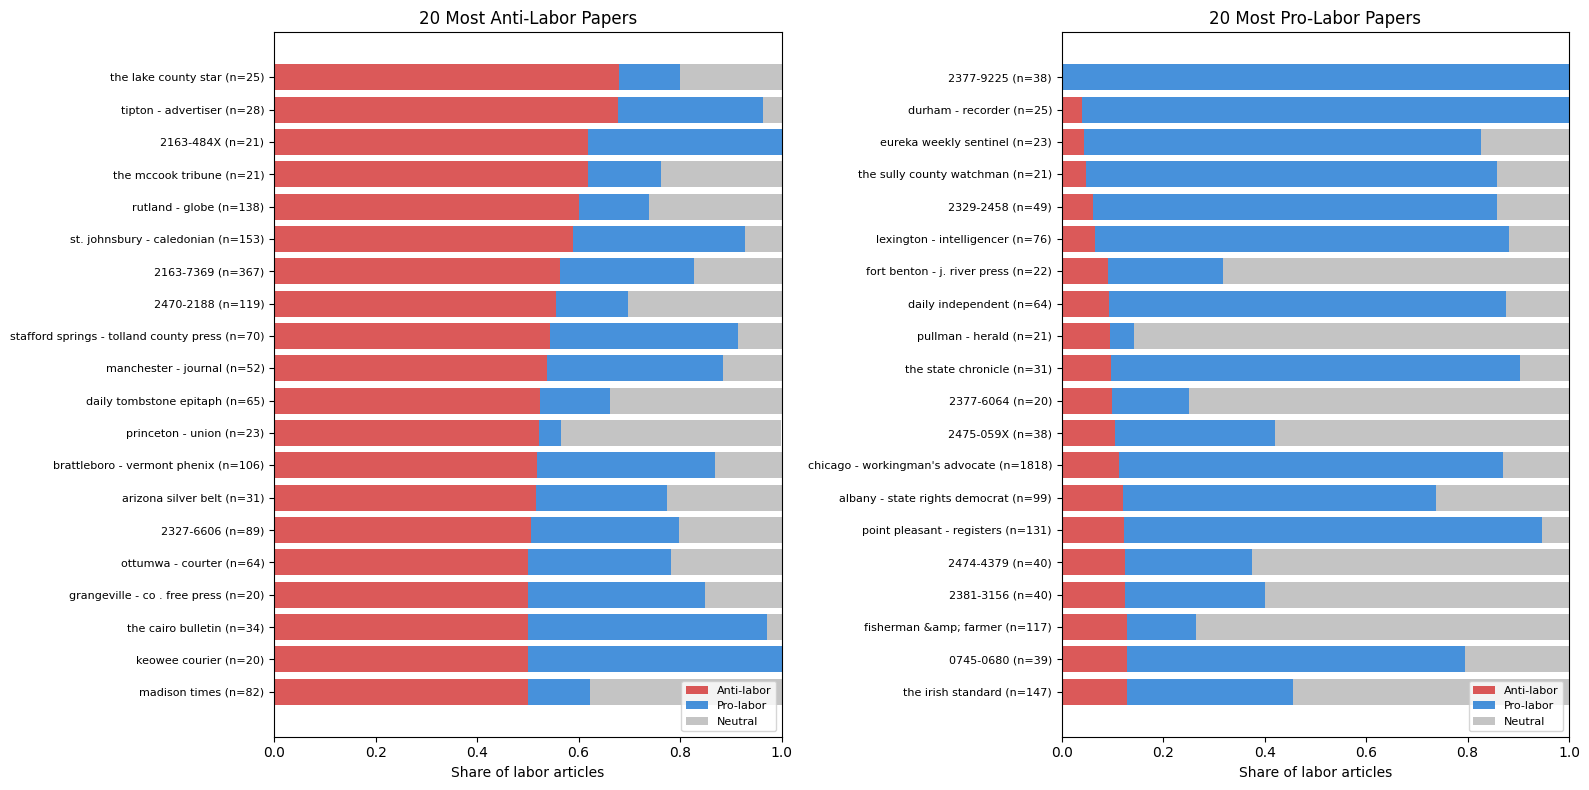

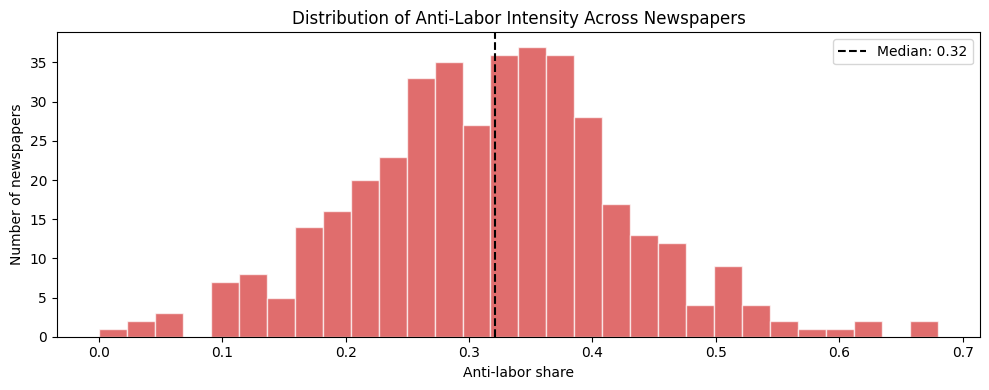

In [8]:
import matplotlib.pyplot as plt

# 8a. Labor sentiment distribution by newspaper
# Use all sentiment data (not just the regression sample)
conn = sqlite3.connect(DB_PATH)
all_sent = pd.read_sql("""
    SELECT issn, year, labor_sentiment
    FROM article_sentiment
    WHERE issn != '' AND labor_sentiment IS NOT NULL
""", conn)
conn.close()

# Aggregate to newspaper level
paper_sent = (
    all_sent.groupby(['issn', 'labor_sentiment']).size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in paper_sent.columns:
        paper_sent[col] = 0

paper_sent['total'] = paper_sent['anti_labor'] + paper_sent['pro_labor'] + paper_sent['neutral']
paper_sent['anti_labor_share'] = paper_sent['anti_labor'] / paper_sent['total']
paper_sent['pro_labor_share'] = paper_sent['pro_labor'] / paper_sent['total']

# Only papers with >= 20 labor articles for meaningful distributions
paper_sent_sig = paper_sent[paper_sent['total'] >= 20].copy()
paper_sent_sig = paper_sent_sig.sort_values('anti_labor_share', ascending=False)

# Add newspaper names from master.csv (covers all papers, not just coded ones)
paper_names = master[['issn', 'newspaper_name', 'town']].dropna(subset=['issn']).drop_duplicates('issn')
paper_sent_sig = paper_sent_sig.merge(paper_names, on='issn', how='left')
paper_sent_sig['label'] = paper_sent_sig.apply(
    lambda r: f"{str(r['town']).strip().lower()} - {str(r['newspaper_name']).strip().lower()}"
    if pd.notna(r['town']) and pd.notna(r['newspaper_name'])
    else str(r['newspaper_name']).strip().lower() if pd.notna(r['newspaper_name'])
    else r['issn'],
    axis=1
)

print(f"Newspapers with >= 20 labor articles: {len(paper_sent_sig)}")

# Plot top/bottom 20
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Most anti-labor
top = paper_sent_sig.head(20)
axes[0].barh(range(len(top)), top['anti_labor_share'], color='#d32f2f', alpha=0.8, label='Anti-labor')
axes[0].barh(range(len(top)), top['pro_labor_share'], left=top['anti_labor_share'], color='#1976d2', alpha=0.8, label='Pro-labor')
axes[0].barh(range(len(top)), 1 - top['anti_labor_share'] - top['pro_labor_share'],
             left=top['anti_labor_share'] + top['pro_labor_share'], color='#9e9e9e', alpha=0.6, label='Neutral')
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels([f"{r['label'][:40]} (n={r['total']})" for _, r in top.iterrows()], fontsize=8)
axes[0].set_title('20 Most Anti-Labor Papers')
axes[0].set_xlabel('Share of labor articles')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].invert_yaxis()

# Most pro-labor
bottom = paper_sent_sig.tail(20).iloc[::-1]
axes[1].barh(range(len(bottom)), bottom['anti_labor_share'], color='#d32f2f', alpha=0.8, label='Anti-labor')
axes[1].barh(range(len(bottom)), bottom['pro_labor_share'], left=bottom['anti_labor_share'], color='#1976d2', alpha=0.8, label='Pro-labor')
axes[1].barh(range(len(bottom)), 1 - bottom['anti_labor_share'] - bottom['pro_labor_share'],
             left=bottom['anti_labor_share'] + bottom['pro_labor_share'], color='#9e9e9e', alpha=0.6, label='Neutral')
axes[1].set_yticks(range(len(bottom)))
axes[1].set_yticklabels([f"{r['label'][:40]} (n={r['total']})" for _, r in bottom.iterrows()], fontsize=8)
axes[1].set_title('20 Most Pro-Labor Papers')
axes[1].set_xlabel('Share of labor articles')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Histogram of anti-labor intensity across all papers
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(paper_sent_sig['anti_labor_share'], bins=30, color='#d32f2f', alpha=0.7, edgecolor='white')
ax.axvline(paper_sent_sig['anti_labor_share'].median(), color='black', linestyle='--', label=f"Median: {paper_sent_sig['anti_labor_share'].median():.2f}")
ax.set_xlabel('Anti-labor share')
ax.set_ylabel('Number of newspapers')
ax.set_title('Distribution of Anti-Labor Intensity Across Newspapers')
ax.legend()
plt.tight_layout()
plt.show()

Persons with >= 20 labor articles during tenure: 208
  Of which railroad_interest=1: 21
  Of which railroad_interest=0: 31
  Uncoded (not in analysis):    156


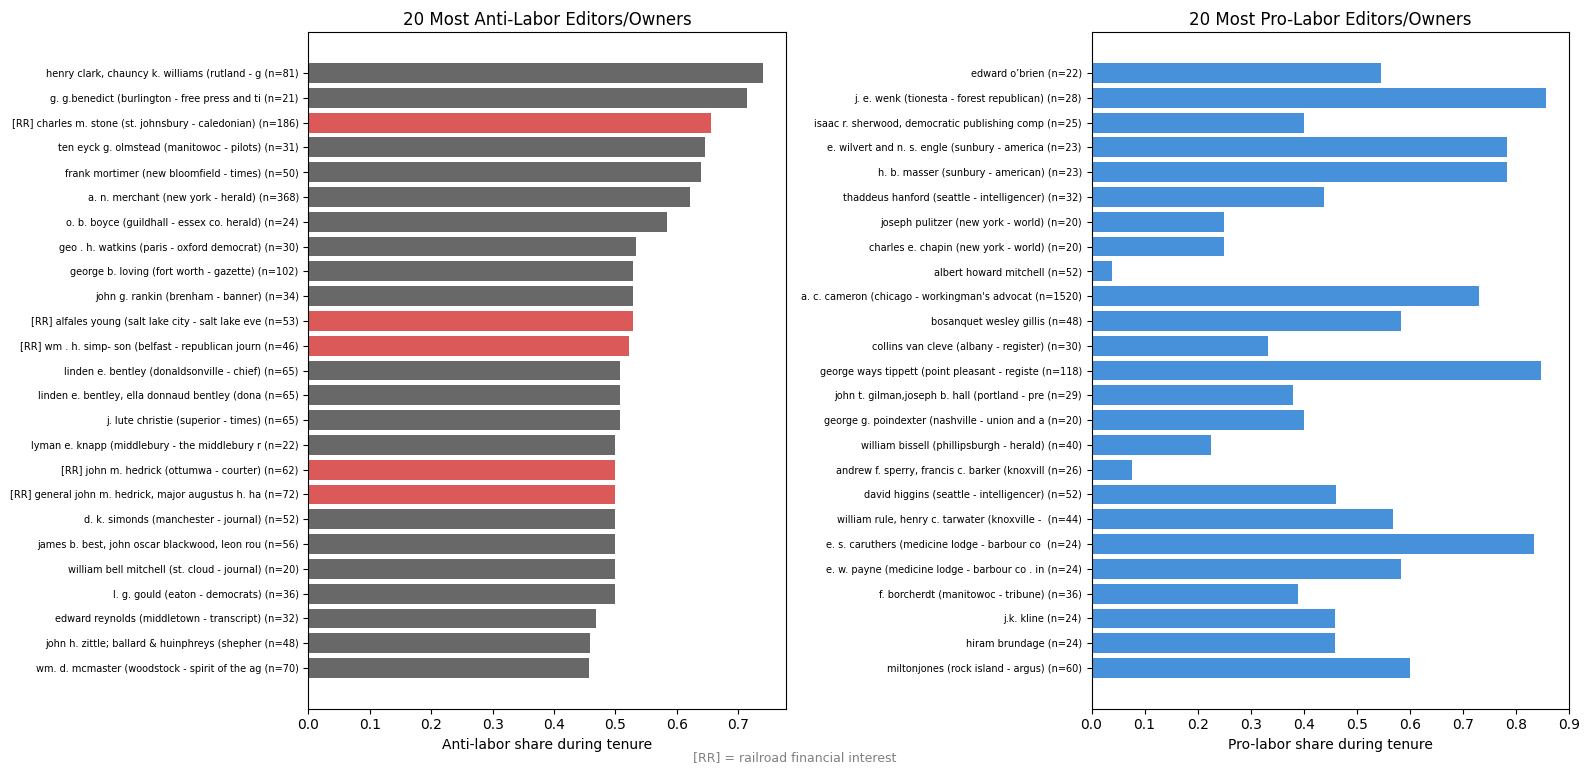

In [9]:
# 8b. Labor sentiment by editor/owner tenure
# For each person, compute sentiment during their active years at each paper

oe_persons_full = oe.dropna(subset=['person_id', 'issn']).copy()
oe_persons_full['person_id'] = oe_persons_full['person_id'].astype(int)

# Expand person-paper-year
tenure_rows = []
for _, row in oe_persons_full.iterrows():
    for yr in parse_years(row['years']):
        tenure_rows.append({
            'issn': row['issn'], 'year': yr,
            'person_id': row['person_id'],
            'name': row['name'],
            'role': row.get('role', ''),
        })

tenure = pd.DataFrame(tenure_rows)

# Merge with article-level sentiment
tenure_sent = tenure.merge(all_sent, on=['issn', 'year'], how='inner')

# Aggregate by person: sentiment distribution during their tenure
person_sent = (
    tenure_sent.groupby(['person_id', 'name', 'labor_sentiment']).size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in person_sent.columns:
        person_sent[col] = 0

person_sent['total'] = person_sent['anti_labor'] + person_sent['pro_labor'] + person_sent['neutral']
person_sent['anti_labor_share'] = person_sent['anti_labor'] / person_sent['total']
person_sent['pro_labor_share'] = person_sent['pro_labor'] / person_sent['total']

# Only persons with >= 20 articles during their tenure
person_sent_sig = person_sent[person_sent['total'] >= 20].copy()
person_sent_sig = person_sent_sig.sort_values('anti_labor_share', ascending=False)

# Add railroad interest coding
person_sent_sig = person_sent_sig.merge(
    person_rr[['person_id', 'railroad_interest']], on='person_id', how='left'
)

# Add newspaper name + city from master.csv via owners_and_editors
person_papers = oe[['person_id', 'issn']].dropna(subset=['person_id']).drop_duplicates()
person_papers['person_id'] = person_papers['person_id'].astype(int)
person_papers = person_papers.merge(paper_names, on='issn', how='left')
# For persons at multiple papers, pick the first
person_paper_label = (
    person_papers.dropna(subset=['newspaper_name'])
    .groupby('person_id')
    .first()
    .reset_index()
)
person_sent_sig = person_sent_sig.merge(
    person_paper_label[['person_id', 'newspaper_name', 'town']], on='person_id', how='left'
)
person_sent_sig['label'] = person_sent_sig.apply(
    lambda r: f"{r['name'].strip().lower()} ({str(r['town']).strip().lower()} - {str(r['newspaper_name']).strip().lower()})"
    if pd.notna(r.get('town')) and pd.notna(r.get('newspaper_name'))
    else f"{r['name'].strip().lower()}" if pd.notna(r['name'])
    else str(r['person_id']),
    axis=1
)

print(f"Persons with >= 20 labor articles during tenure: {len(person_sent_sig)}")
print(f"  Of which railroad_interest=1: {(person_sent_sig['railroad_interest']==1).sum()}")
print(f"  Of which railroad_interest=0: {(person_sent_sig['railroad_interest']==0).sum()}")
print(f"  Uncoded (not in analysis):    {person_sent_sig['railroad_interest'].isna().sum()}")

# Plot top/bottom 20 persons
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_p = person_sent_sig.head(25)
colors_top = ['#d32f2f' if r.get('railroad_interest') == 1 else '#424242' for _, r in top_p.iterrows()]
axes[0].barh(range(len(top_p)), top_p['anti_labor_share'], color=colors_top, alpha=0.8)
axes[0].set_yticks(range(len(top_p)))
axes[0].set_yticklabels([f"{'[RR] ' if r.get('railroad_interest')==1 else ''}{r['label'][:45]} (n={r['total']})"
                         for _, r in top_p.iterrows()], fontsize=7)
axes[0].set_title('20 Most Anti-Labor Editors/Owners')
axes[0].set_xlabel('Anti-labor share during tenure')
axes[0].invert_yaxis()

bot_p = person_sent_sig.tail(25).iloc[::-1]
colors_bot = ['#d32f2f' if r.get('railroad_interest') == 1 else '#1976d2' for _, r in bot_p.iterrows()]
axes[1].barh(range(len(bot_p)), bot_p['pro_labor_share'], color=colors_bot, alpha=0.8)
axes[1].set_yticks(range(len(bot_p)))
axes[1].set_yticklabels([f"{'[RR] ' if r.get('railroad_interest')==1 else ''}{r['label'][:45]} (n={r['total']})"
                         for _, r in bot_p.iterrows()], fontsize=7)
axes[1].set_title('20 Most Pro-Labor Editors/Owners')
axes[1].set_xlabel('Pro-labor share during tenure')
axes[1].invert_yaxis()

plt.suptitle('[RR] = railroad financial interest', fontsize=9, y=0.02, color='gray')
plt.tight_layout()
plt.show()

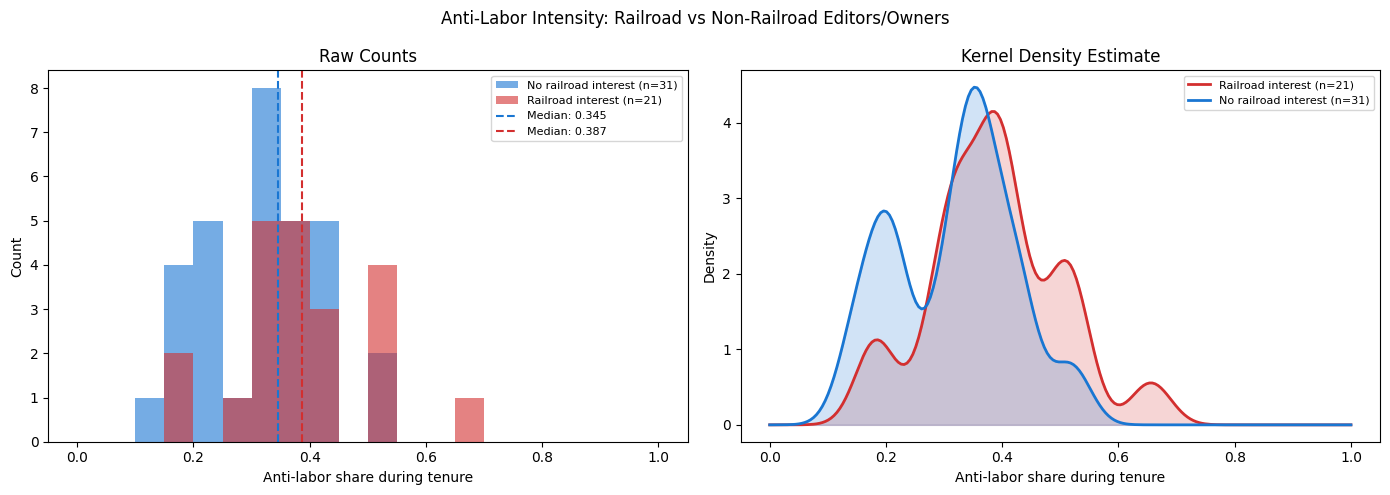

Railroad:     median=0.387, mean=0.388 (n=21)
Non-railroad: median=0.345, mean=0.319 (n=31)
KS test:           D=0.361, p=0.0553
Mann-Whitney U:    U=428, p=0.0571


In [10]:
# 8b continued: Compare distributions by railroad interest
coded = person_sent_sig.dropna(subset=['railroad_interest'])

rr = coded[coded['railroad_interest'] == 1]['anti_labor_share']
no_rr = coded[coded['railroad_interest'] == 0]['anti_labor_share']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw count histograms
bins = np.linspace(0, 1, 21)
axes[0].hist(no_rr, bins=bins, alpha=0.6, color='#1976d2', label=f'No railroad interest (n={len(no_rr)})')
axes[0].hist(rr, bins=bins, alpha=0.6, color='#d32f2f', label=f'Railroad interest (n={len(rr)})')
axes[0].axvline(no_rr.median(), color='#1976d2', linestyle='--', linewidth=1.5, label=f'Median: {no_rr.median():.3f}')
axes[0].axvline(rr.median(), color='#d32f2f', linestyle='--', linewidth=1.5, label=f'Median: {rr.median():.3f}')
axes[0].set_xlabel('Anti-labor share during tenure')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Counts')
axes[0].legend(fontsize=8)

# Right: KDE (smoothed density)
from scipy.stats import gaussian_kde
x_grid = np.linspace(0, 1, 200)
if len(rr) >= 2:
    kde_rr = gaussian_kde(rr, bw_method=0.3)
    axes[1].plot(x_grid, kde_rr(x_grid), color='#d32f2f', linewidth=2, label=f'Railroad interest (n={len(rr)})')
    axes[1].fill_between(x_grid, kde_rr(x_grid), alpha=0.2, color='#d32f2f')
if len(no_rr) >= 2:
    kde_norr = gaussian_kde(no_rr, bw_method=0.3)
    axes[1].plot(x_grid, kde_norr(x_grid), color='#1976d2', linewidth=2, label=f'No railroad interest (n={len(no_rr)})')
    axes[1].fill_between(x_grid, kde_norr(x_grid), alpha=0.2, color='#1976d2')
axes[1].set_xlabel('Anti-labor share during tenure')
axes[1].set_ylabel('Density')
axes[1].set_title('Kernel Density Estimate')
axes[1].legend(fontsize=8)

plt.suptitle('Anti-Labor Intensity: Railroad vs Non-Railroad Editors/Owners', fontsize=12)
plt.tight_layout()
plt.show()

# Statistical tests
from scipy.stats import ks_2samp, mannwhitneyu
ks_stat, ks_p = ks_2samp(rr, no_rr)
u_stat, u_p = mannwhitneyu(rr, no_rr, alternative='two-sided')
print(f"Railroad:     median={rr.median():.3f}, mean={rr.mean():.3f} (n={len(rr)})")
print(f"Non-railroad: median={no_rr.median():.3f}, mean={no_rr.mean():.3f} (n={len(no_rr)})")
print(f"KS test:           D={ks_stat:.3f}, p={ks_p:.4f}")
print(f"Mann-Whitney U:    U={u_stat:.0f}, p={u_p:.4f}")